# Cardiovascular Disease

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# For inline plots in Jupyter
%matplotlib inline

### Load Dataset

In [2]:
file_path = "D:/STUDY/1-Programming/Python-Programs/Mini Project/Cardiovascular_Disease_Dataset.csv"
df = pd.read_csv(file_path)
df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


### Preprocessing

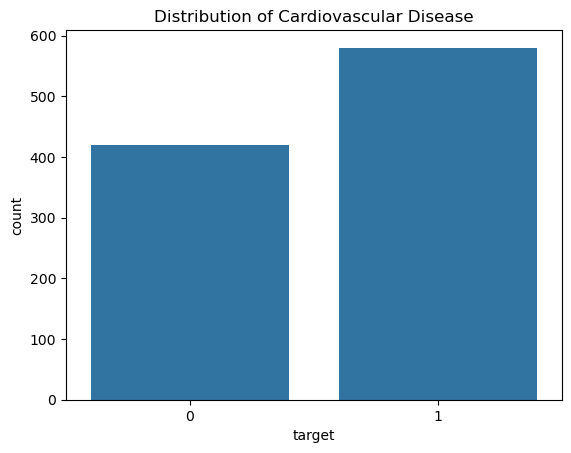

In [3]:
df.isnull().sum()
df = df.dropna()

sns.countplot(x='target', data=df)
plt.title('Distribution of Cardiovascular Disease')
plt.show()

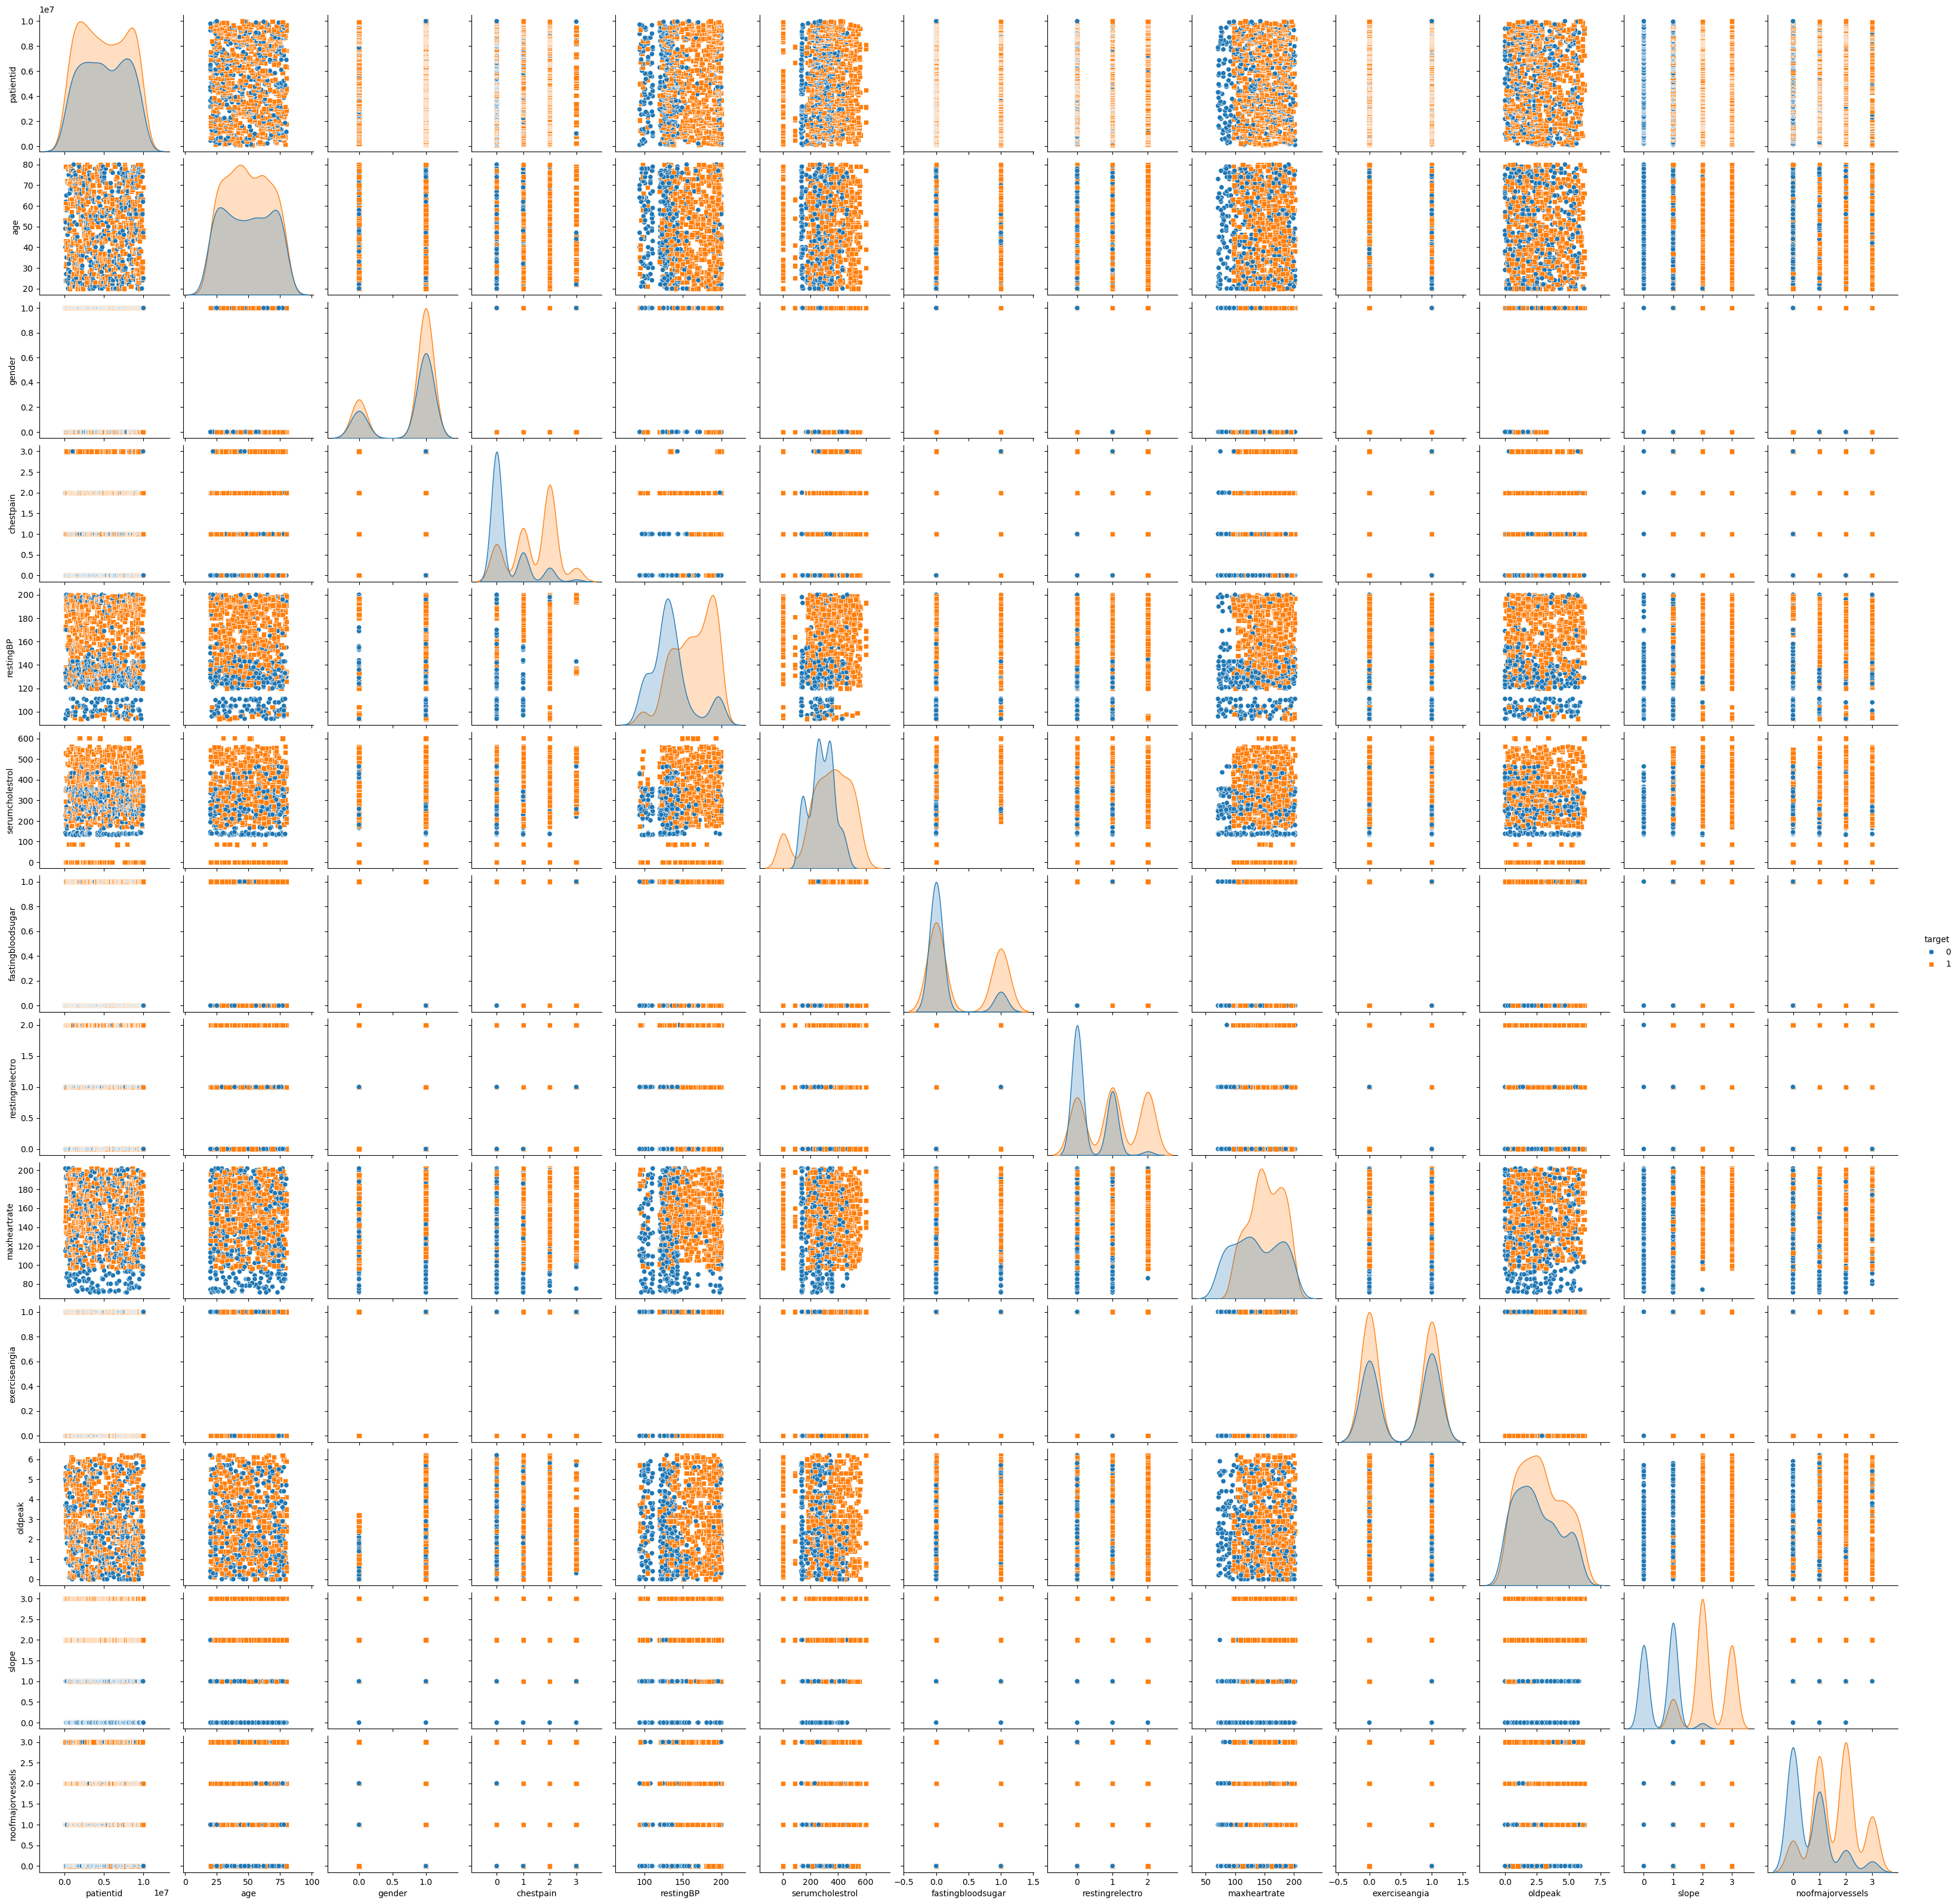

In [4]:
# Pairplot for selected features along with target variable
sns.pairplot(df, hue="target", diag_kind="kde", markers=["o", "s"])
plt.show()

### Train, Test, Split

In [5]:
# dropping unimp columns
df = df.drop(columns=['patientid'])

# Separating features and target variable
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)

### Standardize the features for SVM

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training the SVM Model

In [ ]:
# Training using the RBF kernel 
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=10)
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=10)

### Making Predictions

In [8]:
y_pred = svm_model.predict(X_test_scaled)

### Evaluating the accuracy of the model

In [9]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report

(0.94,
 '              precision    recall  f1-score   support\n\n           0       0.93      0.93      0.93        84\n           1       0.95      0.95      0.95       116\n\n    accuracy                           0.94       200\n   macro avg       0.94      0.94      0.94       200\nweighted avg       0.94      0.94      0.94       200\n')

### Confusion Matrix

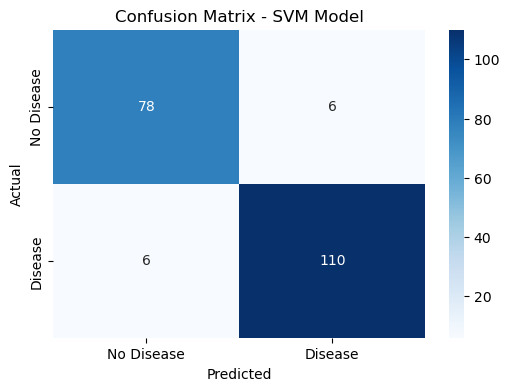

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Model')
plt.show()

### Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly']
}

# Initialising SVM model
svm = SVC()

# Performing grid search
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

best_svm = grid_search.best_estimator_

# Evaluation on test data
y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f'Tuned Model Accuracy: {accuracy_best:.2f}')
# I wrote .2f above to round off the accuracy to 2 decimal places using f-string

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Tuned Model Accuracy: 0.94


### Saving the Model for Future Use

In [13]:
import joblib

joblib.dump(svm_model, 'svm_CVD.pkl')

['svm_CVD.pkl']